In [1]:
from pathlib import Path
from contextlib import nullcontext
import json
import random

import numpy as np
import pandas as pd
from scipy.ndimage import zoom

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [2]:
FOLDER_LEVELS_UP_BEFORE_PREPROCESSING = 2
PREPROCESSING_FOLDER_NAME = "data_preprocessing"
NORMALIZED_DIR_NAME = "Normalized"

COLLECTED_SEGMENTS_PER_SAMPLE = 7
PUBLIC_SEGMENTS_PER_SAMPLE = 2
TARGET_F_BINS = 512
TARGET_T_BINS = 64

BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42

NUM_WORKERS = 0
PIN_MEMORY = True
USE_AMP = True
CUDA_BENCHMARK = True

ANGLE_LOSS_WEIGHT = 1.0
MASS_LOSS_WEIGHT = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = bool(USE_AMP and DEVICE == "cuda")
PIN_MEMORY = bool(PIN_MEMORY and DEVICE == "cuda")

if DEVICE == "cuda" and CUDA_BENCHMARK:
    torch.backends.cudnn.benchmark = True

PREPROCESSING_BASE_DIR = Path.cwd()
for _ in range(FOLDER_LEVELS_UP_BEFORE_PREPROCESSING):
    PREPROCESSING_BASE_DIR = PREPROCESSING_BASE_DIR.parent

PREPROCESSING_ROOT = PREPROCESSING_BASE_DIR / PREPROCESSING_FOLDER_NAME

print("DEVICE:", DEVICE)
print("PREPROCESSING_ROOT:", PREPROCESSING_ROOT)
print("NUM_WORKERS:", NUM_WORKERS)
print("PIN_MEMORY:", PIN_MEMORY)
print("USE_AMP:", USE_AMP)
print("CUDA_BENCHMARK:", CUDA_BENCHMARK)


DEVICE: cuda
PREPROCESSING_ROOT: c:\Users\szymo\Desktop\Wibracje\data_preprocessing
NUM_WORKERS: 0
PIN_MEMORY: True
USE_AMP: True
CUDA_BENCHMARK: True


In [3]:
def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()


def load_npy(path):
    return np.load(path, allow_pickle=True).item()


def segments_for_dataset(dataset_name):
    return {
        "collected": COLLECTED_SEGMENTS_PER_SAMPLE,
        "public": PUBLIC_SEGMENTS_PER_SAMPLE,
    }[dataset_name]


def view_for_task(task):
    return {
        "angle": "tacho",
        "mass": "non_tacho",
        "both": "tacho",
    }[task]


def output_dim_for_task(task):
    return {
        "angle": 2,
        "mass": 1,
        "both": 3,
    }[task]


def resize_segment(X):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[1:] == (TARGET_F_BINS, TARGET_T_BINS):
        return X

    resized = np.empty((X.shape[0], TARGET_F_BINS, TARGET_T_BINS), dtype=np.float32)
    for c in range(X.shape[0]):
        factors = (TARGET_F_BINS / X.shape[1], TARGET_T_BINS / X.shape[2])
        resized[c] = zoom(X[c], factors, order=1).astype(np.float32)
    return resized


def model_output_dirs(model_name, scenario_name):
    model_root = Path.cwd() / "Models" / scenario_name
    weights_dir = model_root / "weight" / model_name
    additional_data_dir = model_root / "additional_data" / model_name
    weights_dir.mkdir(parents=True, exist_ok=True)
    additional_data_dir.mkdir(parents=True, exist_ok=True)
    return weights_dir, additional_data_dir


In [4]:
def collect_files(task, split, datasets):
    view = view_for_task(task)
    files = []
    for dataset_name in datasets:
        folder = PREPROCESSING_ROOT / dataset_name / NORMALIZED_DIR_NAME / view / split
        files.extend(sorted(folder.glob("*.npy")))
    return files


class VibrationRegressionDataset(Dataset):

    def __init__(self, files, task):
        self.files = [Path(p) for p in files]
        self.task = task
        self.samples = []
        self._preload_samples()

    def _build_target(self, labels):
        angle = np.asarray(labels["angle_sin_cos"], dtype=np.float32)
        mass = np.array([labels["imbalance_relative"]], dtype=np.float32)

        if self.task == "angle":
            return angle
        if self.task == "mass":
            return mass
        return np.concatenate([angle, mass]).astype(np.float32)

    def _build_meta(self, path, payload, segment_idx):
        labels = payload["labels"]
        metadata = payload["metadata"]
        return {
            "path": str(path),
            "dataset": metadata["dataset"],
            "source_file": metadata["source_file"],
            "segment_idx": int(segment_idx),
            "imbalance_actual_gmm": float(labels["imbalance_actual_gmm"]),
            "imbalance_relative": float(labels["imbalance_relative"]),
            "angle_deg": float(labels["angle_deg"]),
        }

    def _prepare_segment(self, X, segment_idx, n_segments):
        t_bins = int(X.shape[-1])
        segment_len = t_bins // int(n_segments)
        start = int(segment_idx * segment_len)
        stop = int(start + segment_len)
        return np.ascontiguousarray(resize_segment(X[:, :, start:stop]), dtype=np.float32)

    def _preload_samples(self):
        print(f"Preloading and resizing {len(self.files)} files for task = {self.task}")

        for file_idx, path in enumerate(self.files, start=1):
            payload = load_npy(path)
            X = np.asarray(payload["X"], dtype=np.float32)
            dataset_name = payload["metadata"]["dataset"]
            n_segments = segments_for_dataset(dataset_name)
            y = np.ascontiguousarray(self._build_target(payload["labels"]), dtype=np.float32)

            for segment_idx in range(n_segments):
                self.samples.append({
                    "X": self._prepare_segment(X, segment_idx, n_segments),
                    "y": y.copy(),
                    "meta": self._build_meta(path, payload, segment_idx),
                })

            if file_idx % 50 == 0 or file_idx == len(self.files):
                print(f"  prepared {file_idx}/{len(self.files)} files")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        return {
            "X": torch.from_numpy(sample["X"]),
            "y": torch.from_numpy(sample["y"]),
            "meta": sample["meta"],
        }


def make_loaders(task, datasets):
    train_files = collect_files(task, "train", datasets)
    test_files = collect_files(task, "test", datasets)

    train_ds = VibrationRegressionDataset(train_files, task)
    test_ds = VibrationRegressionDataset(test_files, task)

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 4

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        drop_last=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        test_ds,
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    )
    return train_files, test_files, train_ds, test_ds, train_loader, test_loader


In [5]:
class SimpleSpectrogramCNN(nn.Module):
    def __init__(self, in_channels, out_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(32, out_dim),
        )

    def forward(self, x):
        return self.regressor(self.features(x))


def normalize_sincos(x, eps=1e-8):
    return x / torch.linalg.norm(x, dim=1, keepdim=True).clamp_min(eps)


def task_loss(pred, target, task):
    mse = nn.functional.mse_loss
    if task == "angle":
        return mse(normalize_sincos(pred), target)
    if task == "mass":
        return mse(pred, target)
    angle_loss = mse(normalize_sincos(pred[:, :2]), target[:, :2])
    mass_loss = mse(pred[:, 2:3], target[:, 2:3])
    return ANGLE_LOSS_WEIGHT * angle_loss + MASS_LOSS_WEIGHT * mass_loss


def angle_deg_from_sincos(x):
    sin_v = x[:, 0]
    cos_v = x[:, 1]
    return (np.degrees(np.arctan2(sin_v, cos_v)) + 360) % 360


def circular_mae_deg(pred_sincos, true_sincos):
    pred_deg = angle_deg_from_sincos(pred_sincos)
    true_deg = angle_deg_from_sincos(true_sincos)
    diff = (pred_deg - true_deg + 180) % 360 - 180
    return float(np.mean(np.abs(diff)))


In [6]:
def make_amp_scaler():
    if USE_AMP:
        return torch.amp.GradScaler("cuda", enabled=True)
    return None


def autocast_if_enabled():
    if USE_AMP:
        return torch.amp.autocast("cuda", dtype=torch.float16, enabled=True)
    return nullcontext()


def train_one_epoch(model, loader, optimizer, task, scaler=None):
    model.train()
    losses = []

    for batch in loader:
        X = batch["X"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)
        y = batch["y"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)

        with autocast_if_enabled():
            pred = model(X)
            loss = task_loss(pred, y, task)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses))


def unpack_batch_meta(batch_meta):
    first_value = next(iter(batch_meta.values()))
    batch_size = len(first_value)
    rows = []

    for i in range(batch_size):
        row = {}
        for key, value in batch_meta.items():
            item = value[i]
            if torch.is_tensor(item):
                item = item.item() if item.ndim == 0 else item.detach().cpu().tolist()
            elif isinstance(item, np.generic):
                item = item.item()
            row[key] = item
        rows.append(row)

    return rows


@torch.no_grad()
def evaluate(model, loader, task):
    model.eval()
    losses = []
    preds = []
    targets = []
    metas = []

    for batch in loader:
        X = batch["X"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)
        y = batch["y"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)

        with autocast_if_enabled():
            pred = model(X)
            loss = task_loss(pred, y, task)

        losses.append(float(loss.detach().cpu()))
        preds.append(pred.detach().float().cpu().numpy())
        targets.append(y.detach().cpu().numpy())
        metas.extend(unpack_batch_meta(batch["meta"]))

    pred = np.concatenate(preds, axis=0)
    target = np.concatenate(targets, axis=0)

    metrics = {"loss": float(np.mean(losses))}
    if task in {"angle", "both"}:
        pred_angle = pred[:, :2]
        pred_angle = pred_angle / np.maximum(np.linalg.norm(pred_angle, axis=1, keepdims=True), 1e-8)
        metrics["angle_mae_deg"] = circular_mae_deg(pred_angle, target[:, :2])
    if task == "mass":
        metrics["mass_mae_relative"] = float(np.mean(np.abs(pred[:, 0] - target[:, 0])))
    if task == "both":
        metrics["mass_mae_relative"] = float(np.mean(np.abs(pred[:, 2] - target[:, 2])))

    return metrics, pred, target, metas


def save_predictions(task, pred, target, metas, additional_data_dir):
    rows = []

    for i, meta in enumerate(metas):
        row = dict(meta)

        if task in {"angle", "both"}:
            pred_angle = pred[i, :2]
            pred_angle = pred_angle / max(np.linalg.norm(pred_angle), 1e-8)
            row["angle_pred_deg"] = float(angle_deg_from_sincos(pred_angle.reshape(1, -1))[0])
            row["angle_true_deg"] = float(meta["angle_deg"])

        if task == "mass":
            row["imbalance_relative_pred"] = float(pred[i, 0])
            row["imbalance_relative_true"] = float(target[i, 0])

        if task == "both":
            row["imbalance_relative_pred"] = float(pred[i, 2])
            row["imbalance_relative_true"] = float(target[i, 2])

        rows.append(row)

    predictions_df = pd.DataFrame(rows)
    predictions_df.to_csv(additional_data_dir / "predictions.csv", index=False)
    return predictions_df


In [7]:
def model_plot_title(scope, datasets):
    dataset_label = " + ".join(str(d).capitalize() for d in datasets)
    return {
        "angle": f"{dataset_label} dataset -> angle sin/cos regression",
        "mass": f"{dataset_label} dataset -> imbalance/mass regression",
        "both": f"{dataset_label} dataset -> angle + mass regression",
    }[scope]


def plot_training_loss_curve(history_df, title):
    fig, ax = plt.subplots(figsize=(10.5, 4.0))
    ax.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], label="test loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(f"{title} | loss")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _json_safe(value):
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, pd.DataFrame):
        return _json_safe(value.to_dict(orient="records"))
    if isinstance(value, pd.Series):
        return _json_safe(value.to_dict())
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return _json_safe(value.tolist())
    if isinstance(value, np.generic):
        return _json_safe(value.item())
    if isinstance(value, float) and (np.isnan(value) or np.isinf(value)):
        return None
    return value


def build_metrics_payload(model_name, scope, datasets, metrics, history_df, run_config, scenario_name):
    val_loss = pd.to_numeric(history_df["val_loss"])
    best_idx = int(val_loss.idxmin())
    best_epoch_metrics = _json_safe(history_df.loc[best_idx].to_dict())

    return {
        "model_name": model_name,
        "scope": scope,
        "datasets": list(datasets),
        "scenario_name": scenario_name,
        "final_metrics": _json_safe(metrics),
        "best_epoch": int(history_df.loc[best_idx, "epoch"]),
        "best_epoch_metrics": best_epoch_metrics,
        "training_history": _json_safe(history_df.to_dict(orient="records")),
        "history_columns": list(history_df.columns),
        "run_config": _json_safe(run_config),
    }


def save_metrics_artifacts(model_name, scope, datasets, metrics, history_df, run_config, additional_data_dir, scenario_name):
    payload = build_metrics_payload(
        model_name=model_name,
        scope=scope,
        datasets=datasets,
        metrics=metrics,
        history_df=history_df,
        run_config=run_config,
        scenario_name=scenario_name,
    )

    with open(additional_data_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    history_long = history_df.melt(
        id_vars=["epoch"],
        var_name="metric",
        value_name="value",
    )
    history_long.insert(0, "scenario_name", scenario_name)
    history_long.insert(1, "model_name", model_name)
    history_long.insert(2, "scope", scope)
    history_long.to_csv(additional_data_dir / "history_long.csv", index=False)

    metric_rows = []
    for metric_name, metric_value in metrics.items():
        metric_rows.append({
            "scenario_name": scenario_name,
            "model_name": model_name,
            "scope": scope,
            "metric": metric_name,
            "value": float(metric_value),
            "source": "final_best_model",
        })

    for metric_name, metric_value in payload["best_epoch_metrics"].items():
        if metric_name != "epoch":
            metric_rows.append({
                "scenario_name": scenario_name,
                "model_name": model_name,
                "scope": scope,
                "metric": f"best_epoch_{metric_name}",
                "value": float(metric_value),
                "source": "best_epoch_history",
            })

    pd.DataFrame(metric_rows).to_csv(additional_data_dir / "main_metrics.csv", index=False)


def train_model(model_name, scope, datasets, model, train_files, test_files, train_ds, test_ds, train_loader, test_loader, scenario_name):
    set_seed()
    model = model.to(DEVICE)
    weights_dir, additional_data_dir = model_output_dirs(model_name, scenario_name)
    model_root = Path.cwd() / "Models" / scenario_name

    print(
        f"SCENARIO: {scenario_name} | "
        f"MODEL_NAME: {model_name} | "
        f"SCOPE: {scope} | "
        f"DATASETS: {datasets} | "
        f"train segments: {len(train_files)}/{len(train_ds)} | "
        f"test segments: {len(test_files)}/{len(test_ds)}"
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler = make_amp_scaler()

    best_loss = float("inf")
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scope, scaler=scaler)
        val_metrics, _, _, _ = evaluate(model, test_loader, scope)
        row = {"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}}
        history.append(row)

        if epoch % 10 == 0:
            print(row)

        torch.save(model.state_dict(), weights_dir / "last.pt")
        if val_metrics["loss"] < best_loss:
            best_loss = val_metrics["loss"]
            torch.save(model.state_dict(), weights_dir / "best.pt")

    history_df = pd.DataFrame(history)
    history_df.to_csv(additional_data_dir / "history.csv", index=False)

    model.load_state_dict(torch.load(weights_dir / "best.pt", map_location=DEVICE))
    metrics, pred, target, metas = evaluate(model, test_loader, scope)
    predictions_df = save_predictions(scope, pred, target, metas, additional_data_dir)

    run_config = {
        "model_name": model_name,
        "scope": scope,
        "datasets": list(datasets),
        "scenario_name": scenario_name,
        "preprocessing_root": str(PREPROCESSING_ROOT),
        "model_root": str(model_root),
        "weights_dir": str(weights_dir),
        "additional_data_dir": str(additional_data_dir),
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "random_seed": RANDOM_SEED,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "use_amp": USE_AMP,
        "cuda_benchmark": CUDA_BENCHMARK,
        "device": DEVICE,
    }
    with open(additional_data_dir / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(run_config, f, indent=2, ensure_ascii=False)

    save_metrics_artifacts(
        model_name=model_name,
        scope=scope,
        datasets=datasets,
        metrics=metrics,
        history_df=history_df,
        run_config=run_config,
        additional_data_dir=additional_data_dir,
        scenario_name=scenario_name,
    )

    print("Final metrics:", metrics)
    print("Saved expanded metrics:", additional_data_dir / "metrics.json")
    print("Saved main metrics table:", additional_data_dir / "main_metrics.csv")

    plot_training_loss_curve(
        history_df,
        model_plot_title(scope=scope, datasets=datasets),
    )

    return metrics, predictions_df


In [8]:
def load_label_scaling(dataset_name):
    with open(PREPROCESSING_ROOT / dataset_name / "label_scaling.json", "r", encoding="utf-8") as f:
        return json.load(f)


def imbalance_relative_to_actual_gmm(relative_value, dataset_name):
    scaling = load_label_scaling(dataset_name)
    min_v = float(scaling["dataset_min_gmm"])
    max_v = float(scaling["dataset_max_gmm"])
    return float(relative_value) * (max_v - min_v) + min_v


def _circular_abs_error_deg(true_deg, pred_deg):
    diff = (np.asarray(pred_deg, dtype=float) - np.asarray(true_deg, dtype=float) + 180.0) % 360.0 - 180.0
    return np.abs(diff)


def _series_metric_rows(model_name, metric_name, values, unit):
    values = np.asarray(values, dtype=float)
    return [
        {"model": model_name, "metric": f"{metric_name}_mean", "value": float(np.mean(values)), "unit": unit},
        {"model": model_name, "metric": f"{metric_name}_median", "value": float(np.median(values)), "unit": unit},
        {"model": model_name, "metric": f"{metric_name}_p95", "value": float(np.percentile(values, 95)), "unit": unit},
        {"model": model_name, "metric": f"{metric_name}_max", "value": float(np.max(values)), "unit": unit},
    ]


def add_final_error_columns(predictions_df, scope):
    df = predictions_df.copy().reset_index(drop=True)
    df.insert(0, "sample_index", np.arange(len(df)))

    if scope in {"angle", "both"}:
        df["true_angle_deg"] = df["angle_true_deg"].astype(float)
        df["pred_angle_deg"] = df["angle_pred_deg"].astype(float)
        df["angle_error_deg"] = _circular_abs_error_deg(df["true_angle_deg"], df["pred_angle_deg"])

        true_rad = np.deg2rad(df["true_angle_deg"].to_numpy(dtype=float))
        pred_rad = np.deg2rad(df["pred_angle_deg"].to_numpy(dtype=float))
        df["true_sin"] = np.sin(true_rad)
        df["true_cos"] = np.cos(true_rad)
        df["pred_sin"] = np.sin(pred_rad)
        df["pred_cos"] = np.cos(pred_rad)

    if scope in {"mass", "both"}:
        df["true_value"] = df["imbalance_relative_true"].astype(float)
        df["pred_value"] = df["imbalance_relative_pred"].astype(float)
        df["residual"] = df["pred_value"] - df["true_value"]
        df["abs_error"] = df["residual"].abs()

        df["true_actual_gmm_from_relative"] = [
            imbalance_relative_to_actual_gmm(v, d) for v, d in zip(df["true_value"], df["dataset"])
        ]
        df["pred_actual_gmm_from_relative"] = [
            imbalance_relative_to_actual_gmm(v, d) for v, d in zip(df["pred_value"], df["dataset"])
        ]
        df["residual_actual_gmm"] = df["pred_actual_gmm_from_relative"] - df["true_actual_gmm_from_relative"]
        df["abs_error_actual_gmm"] = df["residual_actual_gmm"].abs()

    return df


def build_final_grade(model_name, scope, predictions_df, metrics):
    rows = [{"model": model_name, "metric": "test_loss_best_model", "value": float(metrics["loss"]), "unit": "MSE"}]

    if scope in {"angle", "both"}:
        rows.append({
            "model": model_name,
            "metric": "test_angle_mae_from_evaluate",
            "value": float(metrics["angle_mae_deg"]),
            "unit": "deg",
        })
        rows.extend(_series_metric_rows(model_name, "angle_abs_error", predictions_df["angle_error_deg"], "deg"))

    if scope in {"mass", "both"}:
        rows.append({
            "model": model_name,
            "metric": "test_mass_mae_from_evaluate",
            "value": float(metrics["mass_mae_relative"]),
            "unit": "relative",
        })
        rows.extend(_series_metric_rows(model_name, "mass_abs_error", predictions_df["abs_error"], "relative"))
        rows.extend(_series_metric_rows(model_name, "mass_abs_error", predictions_df["abs_error_actual_gmm"], "g*mm"))

    return pd.DataFrame(rows)


def save_final_grading(model_name, scope, scenario_name, predictions_df, metrics):
    pred_table = add_final_error_columns(predictions_df, scope=scope)
    grade_table = build_final_grade(model_name, scope, pred_table, metrics=metrics)

    additional_data_dir = Path.cwd() / "Models" / scenario_name / "additional_data" / model_name
    additional_data_dir.mkdir(parents=True, exist_ok=True)
    pred_table.to_csv(additional_data_dir / "final_predictions_with_errors.csv", index=False)
    grade_table.to_csv(additional_data_dir / "final_grade.csv", index=False)

    return pred_table, grade_table


## Train all configured models


Preloading and resizing 308 files for task = angle
  prepared 50/308 files
  prepared 100/308 files
  prepared 150/308 files
  prepared 200/308 files
  prepared 250/308 files
  prepared 300/308 files
  prepared 308/308 files
Preloading and resizing 81 files for task = angle
  prepared 50/81 files
  prepared 81/81 files
SCENARIO: Model_1 | MODEL_NAME: angle_collected | SCOPE: angle | DATASETS: ['collected'] | train segments: 308/2156 | test segments: 81/567
{'epoch': 10, 'train_loss': 0.124427387283908, 'val_loss': 0.373800386985143, 'val_angle_mae_deg': 43.87943649291992}
{'epoch': 20, 'train_loss': 0.06662684389286572, 'val_loss': 0.06907970147828262, 'val_angle_mae_deg': 16.017526626586914}
{'epoch': 30, 'train_loss': 0.04934267244405217, 'val_loss': 0.1307283453643322, 'val_angle_mae_deg': 24.063282012939453}
{'epoch': 40, 'train_loss': 0.03708821369542016, 'val_loss': 0.05646620069940885, 'val_angle_mae_deg': 13.383403778076172}
{'epoch': 50, 'train_loss': 0.025549881781140964, 'va

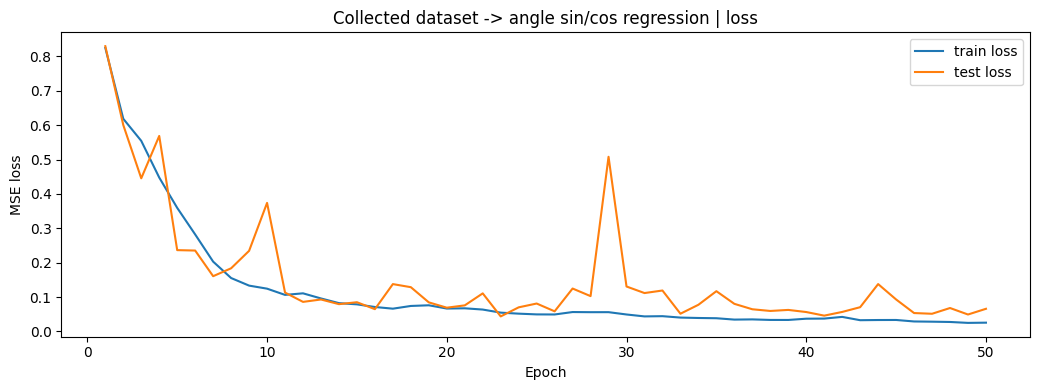

SCENARIO: Model_2 | MODEL_NAME: angle_collected | SCOPE: angle | DATASETS: ['collected'] | train segments: 308/2156 | test segments: 81/567
{'epoch': 10, 'train_loss': 0.17767705685562557, 'val_loss': 0.1490431179602941, 'val_angle_mae_deg': 26.034515380859375}
{'epoch': 20, 'train_loss': 0.08478028410010868, 'val_loss': 0.11233074714740117, 'val_angle_mae_deg': 22.5391788482666}
{'epoch': 30, 'train_loss': 0.05471284149421586, 'val_loss': 0.06370647624135017, 'val_angle_mae_deg': 15.107771873474121}
{'epoch': 40, 'train_loss': 0.04539119038316938, 'val_loss': 0.05542859993875027, 'val_angle_mae_deg': 14.443974494934082}
{'epoch': 50, 'train_loss': 0.08510300020376842, 'val_loss': 0.2526574234167735, 'val_angle_mae_deg': 37.8194580078125}
Final metrics: {'loss': 0.040767447712520756, 'angle_mae_deg': 12.392666816711426}
Saved expanded metrics: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\Model_2\additional_data\angle_collected\metrics.json
Saved main metrics table: c:\Users\sz

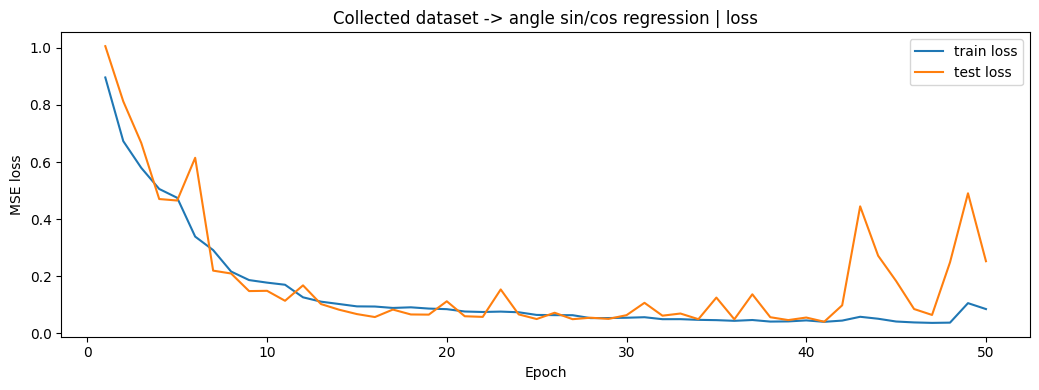

Preloading and resizing 462 files for task = mass
  prepared 50/462 files
  prepared 100/462 files
  prepared 150/462 files
  prepared 200/462 files
  prepared 250/462 files
  prepared 300/462 files
  prepared 350/462 files
  prepared 400/462 files
  prepared 450/462 files
  prepared 462/462 files
Preloading and resizing 123 files for task = mass
  prepared 50/123 files
  prepared 100/123 files
  prepared 123/123 files
SCENARIO: Model_1 | MODEL_NAME: mass_collected | SCOPE: mass | DATASETS: ['collected'] | train segments: 462/3234 | test segments: 123/861
{'epoch': 10, 'train_loss': 0.026912273552555304, 'val_loss': 0.01472037669736892, 'val_mass_mae_relative': 0.09969864040613174}
{'epoch': 20, 'train_loss': 0.02307420324247617, 'val_loss': 0.013377077179029584, 'val_mass_mae_relative': 0.09320676326751709}
{'epoch': 30, 'train_loss': 0.01658337305371578, 'val_loss': 0.00872567284386605, 'val_mass_mae_relative': 0.07347380369901657}
{'epoch': 40, 'train_loss': 0.017278465442359447, 'v

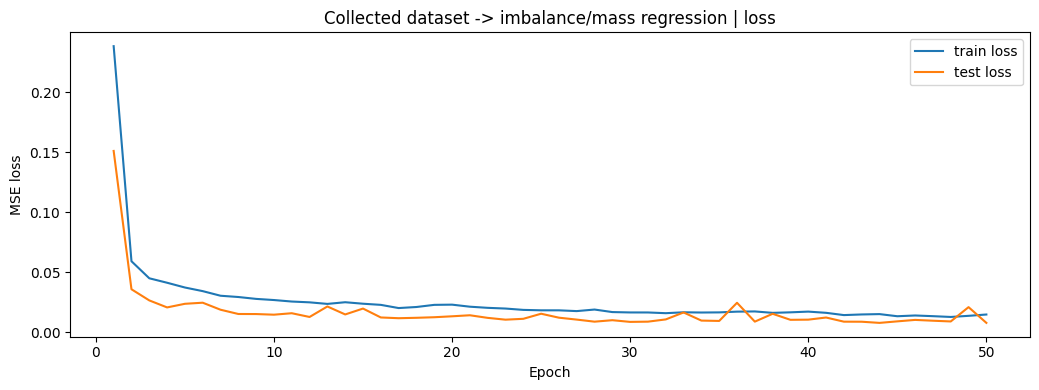

SCENARIO: Model_2 | MODEL_NAME: mass_collected | SCOPE: mass | DATASETS: ['collected'] | train segments: 462/3234 | test segments: 123/861
{'epoch': 10, 'train_loss': 0.030170812343175594, 'val_loss': 0.018113537225872278, 'val_mass_mae_relative': 0.1069282591342926}
{'epoch': 20, 'train_loss': 0.02599651008271254, 'val_loss': 0.011892553884536028, 'val_mass_mae_relative': 0.08997347950935364}
{'epoch': 30, 'train_loss': 0.02002217348378438, 'val_loss': 0.019796633394435048, 'val_mass_mae_relative': 0.10563257336616516}
{'epoch': 40, 'train_loss': 0.01832294550079566, 'val_loss': 0.020794393494725227, 'val_mass_mae_relative': 0.12586507201194763}
{'epoch': 50, 'train_loss': 0.015710643922480252, 'val_loss': 0.014312040410004556, 'val_mass_mae_relative': 0.09258872270584106}
Final metrics: {'loss': 0.0089983626967296, 'mass_mae_relative': 0.07563093304634094}
Saved expanded metrics: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\Model_2\additional_data\mass_collected\metrics.json

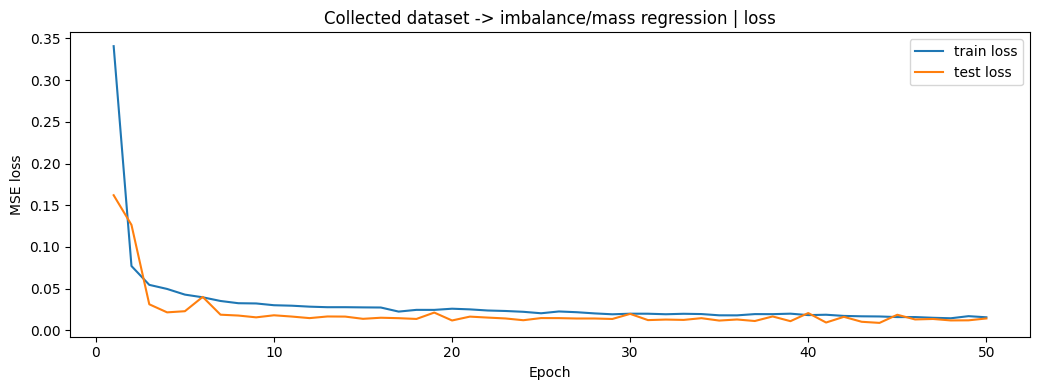

Preloading and resizing 305 files for task = mass
  prepared 50/305 files
  prepared 100/305 files
  prepared 150/305 files
  prepared 200/305 files
  prepared 250/305 files
  prepared 300/305 files
  prepared 305/305 files
Preloading and resizing 77 files for task = mass
  prepared 50/77 files
  prepared 77/77 files
SCENARIO: Model_1 | MODEL_NAME: mass_public | SCOPE: mass | DATASETS: ['public'] | train segments: 305/610 | test segments: 77/154
{'epoch': 10, 'train_loss': 0.07165364548563957, 'val_loss': 0.29423442482948303, 'val_mass_mae_relative': 0.48487645387649536}
{'epoch': 20, 'train_loss': 0.05600539346536001, 'val_loss': 0.09869195520877838, 'val_mass_mae_relative': 0.2429364174604416}
{'epoch': 30, 'train_loss': 0.04612232372164726, 'val_loss': 0.0440547913312912, 'val_mass_mae_relative': 0.15513876080513}
{'epoch': 40, 'train_loss': 0.03665863101681074, 'val_loss': 0.04313645884394646, 'val_mass_mae_relative': 0.15650899708271027}
{'epoch': 50, 'train_loss': 0.0359891441961

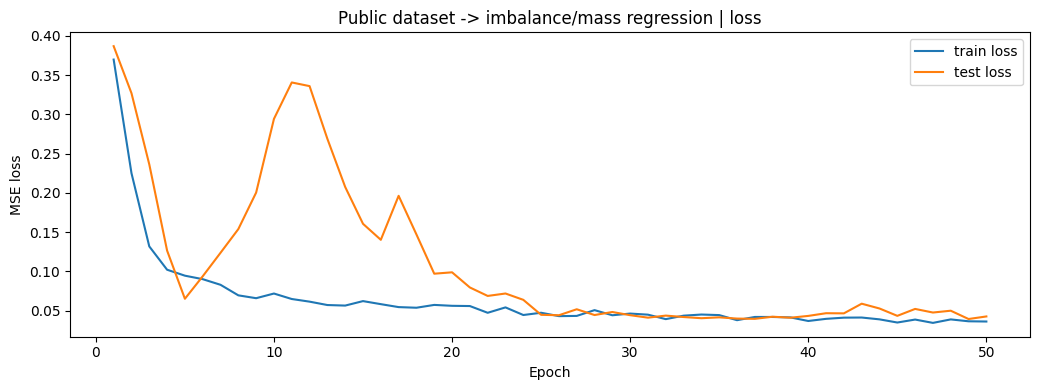

SCENARIO: Model_2 | MODEL_NAME: mass_public | SCOPE: mass | DATASETS: ['public'] | train segments: 305/610 | test segments: 77/154
{'epoch': 10, 'train_loss': 0.08513905107975006, 'val_loss': 0.08681964874267578, 'val_mass_mae_relative': 0.22896598279476166}
{'epoch': 20, 'train_loss': 0.057123709470033646, 'val_loss': 0.09112656861543655, 'val_mass_mae_relative': 0.23397763073444366}
{'epoch': 30, 'train_loss': 0.04628011335929235, 'val_loss': 0.044012803584337234, 'val_mass_mae_relative': 0.15639938414096832}
{'epoch': 40, 'train_loss': 0.03881958375374476, 'val_loss': 0.04266420751810074, 'val_mass_mae_relative': 0.15624378621578217}
{'epoch': 50, 'train_loss': 0.03540544584393501, 'val_loss': 0.04762408882379532, 'val_mass_mae_relative': 0.1682886779308319}
Final metrics: {'loss': 0.039150990545749664, 'mass_mae_relative': 0.1503695547580719}
Saved expanded metrics: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\Model_2\additional_data\mass_public\metrics.json
Saved main met

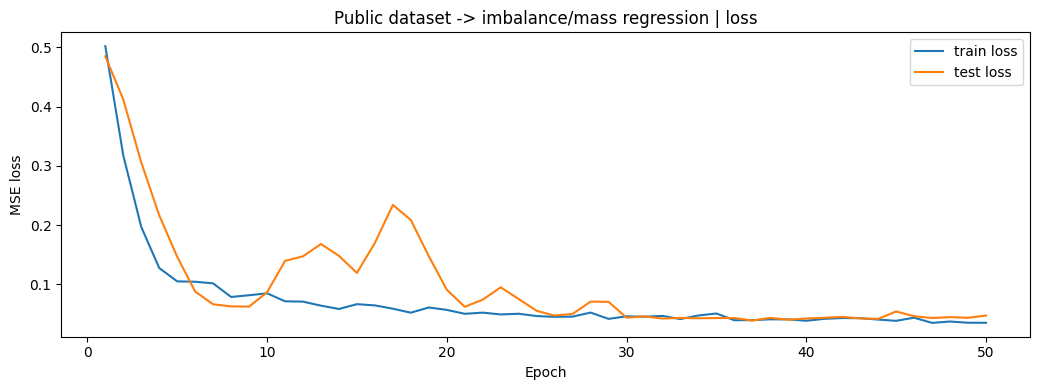

Preloading and resizing 308 files for task = both
  prepared 50/308 files
  prepared 100/308 files
  prepared 150/308 files
  prepared 200/308 files
  prepared 250/308 files
  prepared 300/308 files
  prepared 308/308 files
Preloading and resizing 81 files for task = both
  prepared 50/81 files
  prepared 81/81 files
SCENARIO: Model_1 | MODEL_NAME: angle_mass_collected | SCOPE: both | DATASETS: ['collected'] | train segments: 308/2156 | test segments: 81/567
{'epoch': 10, 'train_loss': 0.2103686597612169, 'val_loss': 0.49731968839963275, 'val_angle_mae_deg': 43.259281158447266, 'val_mass_mae_relative': 0.2793814241886139}
{'epoch': 20, 'train_loss': 0.1254699726899465, 'val_loss': 0.12461446225643158, 'val_angle_mae_deg': 18.408809661865234, 'val_mass_mae_relative': 0.13895964622497559}
{'epoch': 30, 'train_loss': 0.09501334528128307, 'val_loss': 0.06591942409674327, 'val_angle_mae_deg': 12.697443008422852, 'val_mass_mae_relative': 0.11984361708164215}
{'epoch': 40, 'train_loss': 0.074

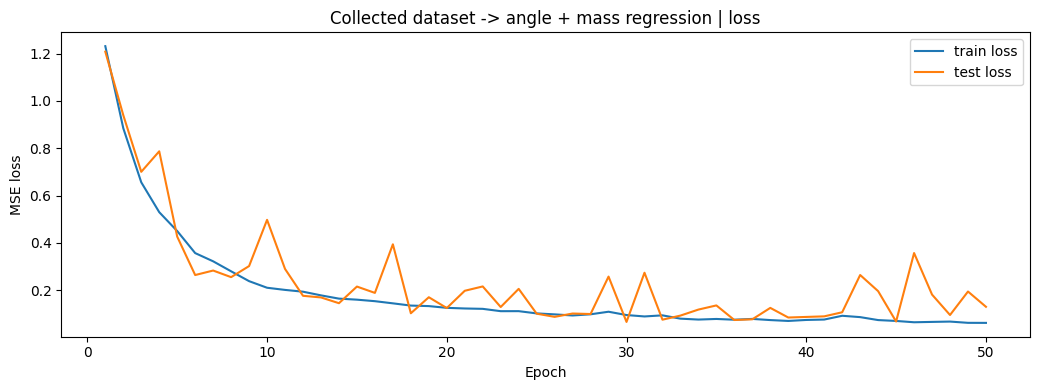

SCENARIO: Model_2 | MODEL_NAME: angle_mass_collected | SCOPE: both | DATASETS: ['collected'] | train segments: 308/2156 | test segments: 81/567
{'epoch': 10, 'train_loss': 0.29443299770355225, 'val_loss': 0.23537000020345053, 'val_angle_mae_deg': 31.005043029785156, 'val_mass_mae_relative': 0.18515661358833313}
{'epoch': 20, 'train_loss': 0.139819805820783, 'val_loss': 0.12504898384213448, 'val_angle_mae_deg': 21.34814453125, 'val_mass_mae_relative': 0.1224491074681282}
{'epoch': 30, 'train_loss': 0.10100452850262324, 'val_loss': 0.07062148054440816, 'val_angle_mae_deg': 14.413132667541504, 'val_mass_mae_relative': 0.10311747342348099}
{'epoch': 40, 'train_loss': 0.07678709758652581, 'val_loss': 0.13333376248677573, 'val_angle_mae_deg': 21.270097732543945, 'val_mass_mae_relative': 0.14812913537025452}
{'epoch': 50, 'train_loss': 0.06189188899265395, 'val_loss': 0.051142483949661255, 'val_angle_mae_deg': 11.286055564880371, 'val_mass_mae_relative': 0.09522596746683121}
Final metrics: {'

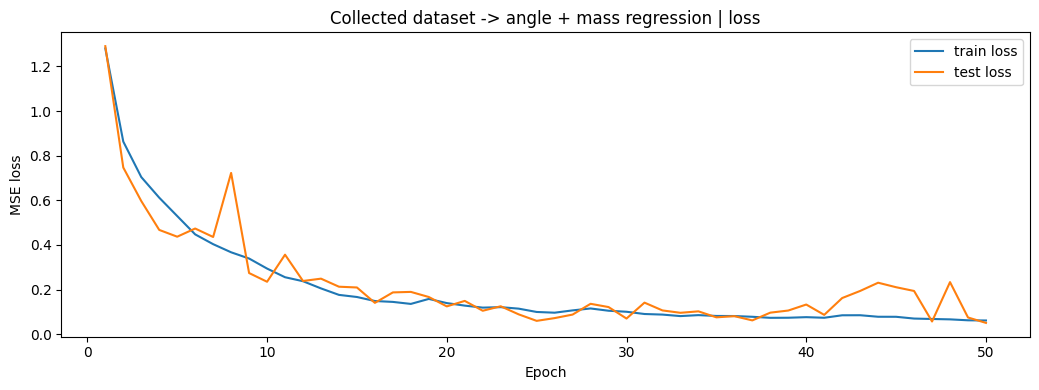

In [9]:
# =============================================================================
# TRAINING CONFIGURATION: all
# =============================================================================

CONFIGURATIONS = [
    {"model_name": "angle_collected", "scope": "angle", "datasets": ["collected"]},
    {"model_name": "mass_collected", "scope": "mass", "datasets": ["collected"]},
    {"model_name": "mass_public", "scope": "mass", "datasets": ["public"]},
    {"model_name": "angle_mass_collected", "scope": "both", "datasets": ["collected"]},
]

for config in CONFIGURATIONS:
    MODEL_NAME = config["model_name"]
    SCOPE = config["scope"]
    DATASETS = config["datasets"]

    train_files, test_files, train_ds, test_ds, train_loader, test_loader = make_loaders(SCOPE, DATASETS)
    example = train_ds[0]
    in_channels = int(example["X"].shape[0])

    MODELS = [
        ("Model_1", SimpleSpectrogramCNN(in_channels=in_channels, out_dim=output_dim_for_task(SCOPE))),
        ("Model_2", SimpleSpectrogramCNN(in_channels=in_channels, out_dim=output_dim_for_task(SCOPE))),
    ]   ### TUTAJ MOŻNA DEFINIOWAĆ WIĘCEJ MODEL 

    for MODEL_SCENARIO_NAME, MODEL in MODELS:
        metrics, predictions = train_model(
            model_name=MODEL_NAME,
            scenario_name=MODEL_SCENARIO_NAME,
            scope=SCOPE,
            datasets=DATASETS,
            model=MODEL,
            train_files=train_files,
            test_files=test_files,
            train_ds=train_ds,
            test_ds=test_ds,
            train_loader=train_loader,
            test_loader=test_loader,
        )

        save_final_grading(
            model_name=MODEL_NAME,
            scenario_name=MODEL_SCENARIO_NAME,
            scope=SCOPE,
            predictions_df=predictions,
            metrics=metrics,
        )
